In [1]:
import os
import glob
import time
from io import BytesIO
from itertools import product

import numpy as np
import uproot
import ROOT
from ROOT import RooFit as RF
from IPython.display import display, Image as IPyImage, display as ipydisplay
from PIL import Image as PILImage

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

ROOT.EnableImplicitMT()
ROOT.gROOT.SetBatch(True)

# Custom HILL/HORNS PDFs, compiled standalone against this ROOT build.
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))

def build_masses(arr):
    """B mass recomputed under the pion and kaon bachelor hypotheses."""
    pD, thD, phD = arr["lab2_P"], arr["lab2_THETA"], arr["lab2_PHI"]
    mD = arr["lab2_MASS"]
    pB, thB, phB = arr["lab1_P"], arr["lab1_THETA"], arr["lab1_PHI"]
    s, c = np.sin, np.cos
    pxD = pD*s(thD)*c(phD); pyD = pD*s(thD)*s(phD); pzD = pD*c(thD)
    pxB = pB*s(thB)*c(phB); pyB = pB*s(thB)*s(phB); pzB = pB*c(thB)
    ED  = np.sqrt(pD**2 + mD**2)
    Epi = np.sqrt(pB**2 + M_PI**2)
    EK  = np.sqrt(pB**2 + M_K**2)
    px, py, pz = pxD+pxB, pyD+pyB, pzD+pzB
    p2 = px**2 + py**2 + pz**2
    mB_pi = np.sqrt(np.maximum((ED + Epi)**2 - p2, 0))
    mB_K  = np.sqrt(np.maximum((ED + EK )**2 - p2, 0))
    return mB_pi, mB_K

Welcome to JupyROOT 6.30/02



0

fit status: 3
Minuit2Minimizer: Minimize with max-calls 2000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Invalid Minimum - status = 3
FVAL  = 117541
Edm   = 0.744592
Nfcn  = 261



Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       117541.5022 Edm =       0.381641674 NCalls =     15
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 117541.5022
  Edm           : 0.381641674
  Internal parameters:	[                0                0    -0.8911225079    -0.9287974735]	
  Internal gradient  :	[    -0.8026317166     -2.440016825      5.892151702      21.18529752]	
  Internal covariance matrix:
[[   0.0022977719              0              0              0]
 [              0    0.096645405              0              0]
 [              0              0    0.011326569              0]
 [              0              0              0   0.0012398395]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 2000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       117541.5022 Edm =       0.381641674 NCalls =     15

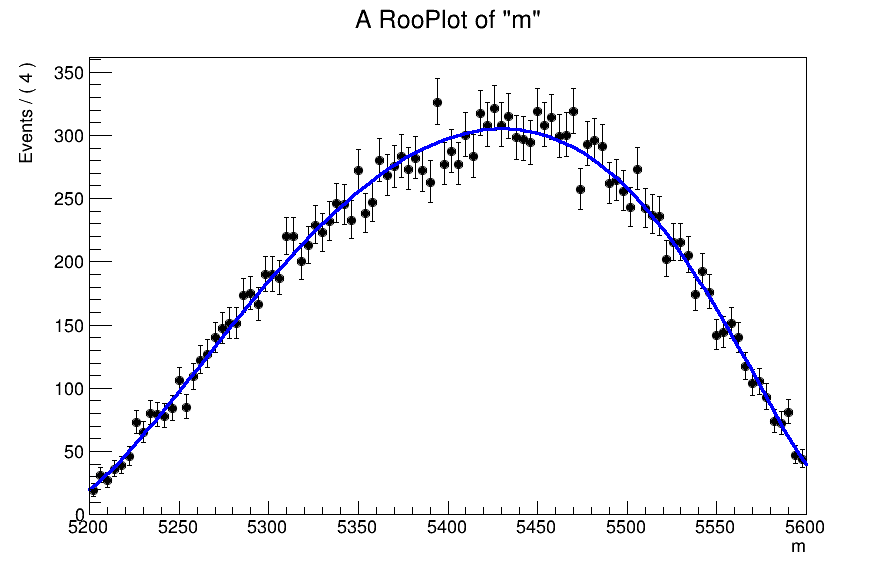

In [2]:
m  = ROOT.RooRealVar("m","m",5200,5600)
a  = ROOT.RooRealVar("a","a",5200); b = ROOT.RooRealVar("b","b",5600)
csi = ROOT.RooRealVar("csi","csi",0.5,0,1)
shift=ROOT.RooRealVar("shift","shift",0)
sigma=ROOT.RooRealVar("sigma","sigma",20,0.1,200)
rs   =ROOT.RooRealVar("ratio_sigma","ratio_sigma",2.0,1.0,10.0)
fs   =ROOT.RooRealVar("fraction_sigma","fraction_sigma",0.5,0,1)

pdf = ROOT.RooHILLdini("hill","HILLdini", m,a,b,csi,shift,sigma,rs,fs)
data = pdf.generate(ROOT.RooArgSet(m), 20000)
res  = pdf.fitTo(data, ROOT.RooFit.Save(True))
print("fit status:", res.status())

frame = m.frame(); data.plotOn(frame); pdf.plotOn(frame)
c = ROOT.TCanvas("c","RooHILLdini",900,600); frame.Draw()
frame.Draw()
c.Update()

Class available? True
fit status: 3
Minuit2Minimizer: Minimize with max-calls 2000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Invalid Minimum - status = 3
FVAL  = 114027
Edm   = 3.08957
Nfcn  = 207



Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       114030.4715 Edm =       3.497342015 NCalls =     19
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 114030.4715
  Edm           : 3.497342015
  Internal parameters:	[                0                0    -0.8911225079    -0.9287974735]	
  Internal gradient  :	[     -111.1224688      14.81462582     -33.71260143     -121.4451846]	
  Internal covariance matrix:
[[  0.00083548609              0              0              0]
 [              0   0.0070356044              0              0]
 [              0              0   0.0007511731              0]
 [              0              0              0  8.6430123e-05]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 2000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       114030.4715 Edm =       3.497342015 NCalls =     19

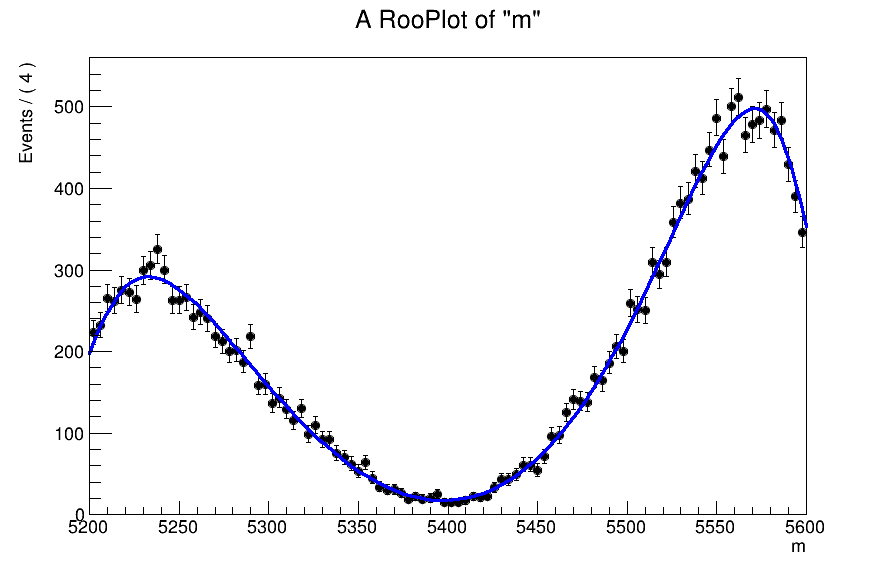

In [3]:
# Load the compiled library
print("Class available?", hasattr(ROOT, "RooHORNSdini"))

# Observable and shape parameters
m  = ROOT.RooRealVar("m","m",5200,5600)
a  = ROOT.RooRealVar("a","a",5200)
b  = ROOT.RooRealVar("b","b",5600)
csi = ROOT.RooRealVar("csi","csi",0.5,0,1)
shift = ROOT.RooRealVar("shift","shift",0)
sigma = ROOT.RooRealVar("sigma","sigma",20,0.1,200)
rs = ROOT.RooRealVar("ratio_sigma","ratio_sigma",2.0,1.0,10.0)
fs = ROOT.RooRealVar("fraction_sigma","fraction_sigma",0.5,0,1)

# Build the PDF and fit
pdf = ROOT.RooHORNSdini("horn","HORNSdini", m,a,b,csi,shift,sigma,rs,fs)
data = pdf.generate(ROOT.RooArgSet(m), 20000)
res = pdf.fitTo(data, ROOT.RooFit.Save(True))
print("fit status:", res.status())

# Plot
frame = m.frame()
data.plotOn(frame)
pdf.plotOn(frame)

c = ROOT.TCanvas("c","RooHORNSdini",900,600)
frame.Draw()
c.Draw()  # shows the canvas directly in Jupyter

In [4]:
ROOT.gROOT.SetBatch(False)   # must be False for interactive display
ROOT.gSystem.Load("libJSRoot")

-1

Error in <TUnixSystem::FindDynamicLibrary>: libJSRoot[.so | .dll | .dylib | .sl | .dl | .a] does not exist in /cvmfs/sft.cern.ch/lcg/releases/MCGenerators/thepeg/2.2.3-3c3f6/x86_64-el9-gcc13-opt/lib/ThePEG:/cvmfs/sft.cern.ch/lcg/releases/MCGenerators/herwig++/7.2.3-46eae/x86_64-el9-gcc13-opt/lib/Herwig:/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/jaxlib/mlir/_mlir_libs:/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/torch/lib:/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/onnxruntime/capi/:/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/tensorflow:/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/tensorflow/contrib/tensor_forest:/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/tensorflow/python/framework:/cvmfs/sft.cern.ch/lcg/releases/java/8u362-88cd4/x86_64-e

In [2]:
FILES = ["root://eoslhcb.cern.ch//eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision25/BD2DPI.ROOT/00316717/0000/00316717_00000007_1.bd2dpi.root"]

### no cuts

### cuts

Custom PDFs loaded: True True

[build] applying full selection cuts



Reading tuples: 8it [00:17,  2.17s/it]



[build] done in 17.4s — entries: 10000

[fit] starting… unbinned extended likelihood fit
[fit] done in 39.2s, status=3



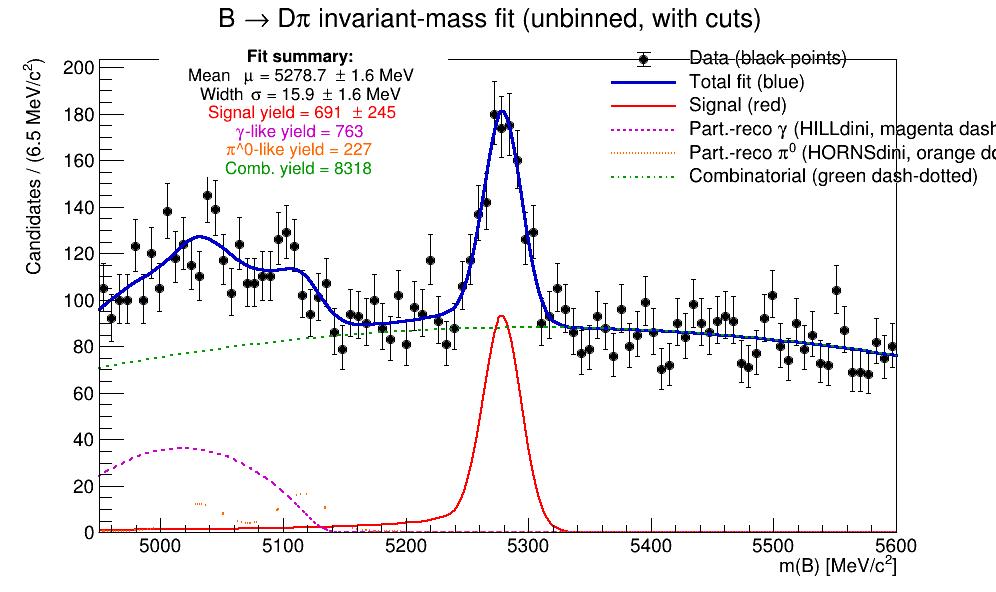


] 
INFO:NumericIntegration -- RooRealIntegral::init([#BKG_g_Int[m]) using numeric integrator RooRombergIntegrator1 to calculate Int] INFO:(NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
m)


[39 RooFit INFO/Eval messages suppressed for readability]


Info in <TCanvas::Print>: png file /tmp/fit_1762018601.png has been created



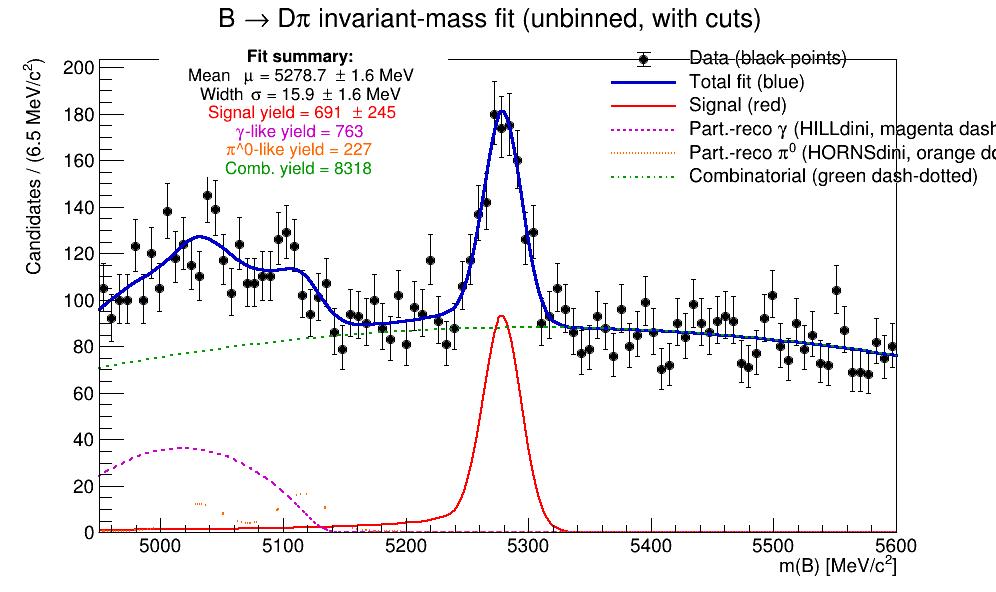

In [6]:
 # input tuples
TREE_PATH  = "Tuple_Bd2DPi/DecayTree"

USE_SUBSET = True
SUBSET_N   = 10000
COMB_MODEL = "cheby"    # or "cheby"

D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MAX = 0.0
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.
ROOT.gROOT.SetBatch(True)

# Load custom PDFs
print("Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))

# Build masses
# Build dataset with cuts
m  = ROOT.RooRealVar("m","B mass [MeV]", mmin, mmax)
ds = ROOT.RooDataSet("ds_pi","Dπ data (with cuts)", ROOT.RooArgSet(m))

branches = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab2_P","lab2_THETA","lab2_PHI","lab1_P","lab1_THETA","lab1_PHI"
]

print("\n[build] applying full selection cuts")
need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="50 MB",
                   library="np", allow_missing=True),
    desc="Reading tuples"
):
    finite = np.isfinite(arrays["lab0_MASS"]) & np.isfinite(arrays["lab0_END_VCHI2DOF"]) \
           & np.isfinite(arrays["lab2_END_VCHI2DOF"]) & np.isfinite(arrays["lab2_MASS"]) \
           & np.isfinite(arrays["lab1_PIDK"]) & np.isfinite(arrays["lab2_P"]) \
           & np.isfinite(arrays["lab2_THETA"]) & np.isfinite(arrays["lab2_PHI"]) \
           & np.isfinite(arrays["lab1_P"]) & np.isfinite(arrays["lab1_THETA"]) \
           & np.isfinite(arrays["lab1_PHI"])

    # Full selection (PIDK, vertex chi2, D mass window)
    sel = (finite
           & (arrays["lab1_PIDK"] < BACHELOR_PIDK_MAX)
           & (arrays["lab0_END_VCHI2DOF"] < B_END_VCHI2DOF_MAX)
           & (arrays["lab2_END_VCHI2DOF"] < D_END_VCHI2DOF_MAX)
           & (np.abs(arrays["lab2_MASS"] - D_MASS) < D_WINDOW))

    mB_pi, _ = build_masses(arrays)
    vals = mB_pi[sel]
    if USE_SUBSET and got < need:
        vals = vals[: int(max(0, need - got))]

    for x in vals:
        if mmin < x < mmax:
            m.setVal(x)
            ds.add(ROOT.RooArgSet(m))
            got += 1
    if got >= need: break

print(f"[build] done in {time.time()-t0:.1f}s — entries: {ds.numEntries()}")

# Model (with physical constraints)
mu  = ROOT.RooRealVar("mu","mean",5280,5200,5360)
sig = ROOT.RooRealVar("sig","sigma",12,8,30)
aL,nL = ROOT.RooRealVar("aL","aL",1.5,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
aR,nR = ROOT.RooRealVar("aR","aR",2.0,0.5,6), ROOT.RooRealVar("nR","nR",3,1,20)
sigL = ROOT.RooCBShape("sigL","left CB",  m, mu, sig, aL, nL)
sigR = ROOT.RooCBShape("sigR","right CB", m, mu, sig, aR, nR)
fLR  = ROOT.RooRealVar("fLR","frac left",0.5,0,1)
SIG  = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# HILLdini (γ-like, below B peak)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL edge",120,60,200)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.4,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",18,8,35)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

# HORNSdini (π-like, also below B peak)
r_a  = ROOT.RooRealVar("r_a","HORNS a",5000,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS edge",80,40,150)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.3,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",22,8,40)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# Combinatorial background
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",-1e-3,-5e-3,0.0)
    BKG_comb = ROOT.RooExponential("BKG_comb","combinatorial", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0",0.0,-1.0,1.0)
    c1 = ROOT.RooRealVar("c1","c1",-0.1,-1.0,0.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","combinatorial", m, ROOT.RooArgList(c0,c1))

Nsig  = ROOT.RooRealVar("Nsig","signal yield",  1e4, 0, 1e9)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",   3e3, 0, 1e9)
Npi   = ROOT.RooRealVar("Npi", "pi-like yield", 3e3, 0, 1e9)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",   1e4, 0, 1e9)

pdf = ROOT.RooAddPdf("pdf","Dπ model",
                     ROOT.RooArgList(SIG, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig,Ng,Npi,Ncomb))

# FIT
print("\n[fit] starting… unbinned extended likelihood fit")
tfit = time.time()
fitres = pdf.fitTo(ds,
                   RF.Strategy(1),
                   RF.NumCPU(4),
                   RF.Extended(True),
                   RF.Minimizer("Minuit2","Migrad"),
                   RF.Save(True),
                   RF.PrintLevel(-1))
print(f"[fit] done in {time.time()-tfit:.1f}s, status={fitres.status()}")

# Final styled plot with proper legend colors and symbols
frame = m.frame(RF.Title("B #rightarrow D#pi invariant-mass fit (unbinned, with cuts)"))
ds.plotOn(frame, RF.Name("data"))

# total + components
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

# Canvas
c = ROOT.TCanvas(f"c_{int(time.time())}","B2Dpi Fit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / (6.5 MeV/c^{2})")
frame.Draw()

# Legend with true colors and styles
leg = ROOT.TLegend(0.60, 0.68, 0.97, 0.92)
leg.SetFillStyle(0)
leg.SetBorderSize(0)
leg.SetTextFont(42)
leg.SetTextSize(0.035)

# Retrieve plotted objects by their names to ensure matching styles
obj_data  = frame.findObject("data")
obj_total = frame.findObject("total")
obj_sig   = frame.findObject("sig_line")
obj_hill  = frame.findObject("hill_line")
obj_horn  = frame.findObject("horn_line")
obj_comb  = frame.findObject("comb_line")

leg.AddEntry(obj_data,  "Data (black points)", "pe")
leg.AddEntry(obj_total, "Total fit (blue)",    "l")
leg.AddEntry(obj_sig,   "Signal (red)",        "l")
leg.AddEntry(obj_hill,  "Part.-reco #gamma (HILLdini, magenta dashed)", "l")
leg.AddEntry(obj_horn,  "Part.-reco #pi^{0} (HORNSdini, orange dotted)", "l")
leg.AddEntry(obj_comb,  "Combinatorial (green dash-dotted)", "l")
leg.Draw()

# Fit summary box (colored text)
box = ROOT.TPaveText(0.16, 0.70, 0.45, 0.92, "NDC")
box.SetFillColor(0)
box.SetBorderSize(0)
box.SetTextFont(42)
box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")

t = box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
t.SetTextColor(ROOT.kBlack)
t = box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.1f} MeV")
t.SetTextColor(ROOT.kBlack)

t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}")
t.SetTextColor(ROOT.kRed)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f}")
t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f}")
t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f}")
t.SetTextColor(ROOT.kGreen+2)
box.Draw()

# Show inline (temporary PNG, lxplus-safe)
c.Modified()
c.Update()
ROOT.gSystem.ProcessEvents()

tmp_png = f"/tmp/fit_{int(time.time())}.png"
c.SaveAs(tmp_png)

ipydisplay(IPyImage(filename=tmp_png))

## Binned fits + better fit

Custom PDFs loaded: True True

[build] applying Dπ cuts and skimming...



Reading tuples: 0it [00:00, ?it/s]


Reading tuples: 12it [00:36,  3.03s/it]



[build] done in 37.2s — kept 7121538 events

[fit] binned (Poisson) likelihood, NBINS = 280
[fit] time: 2.2s, status=3



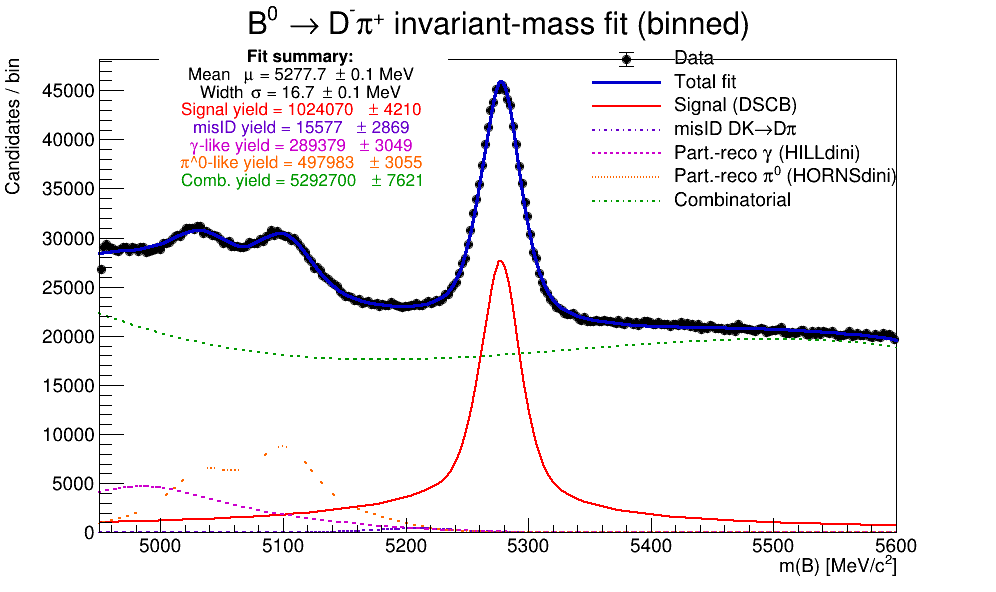

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).



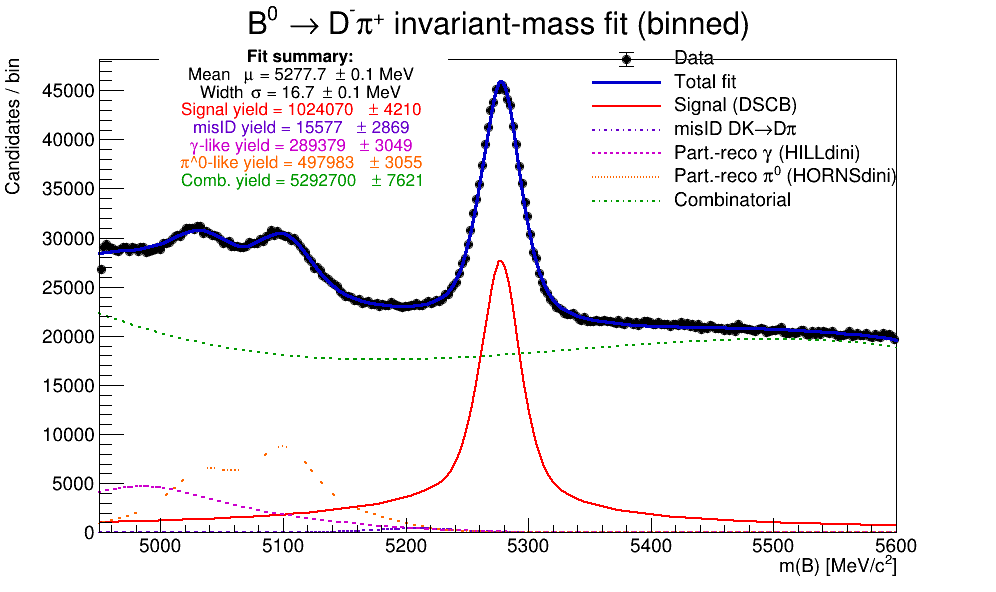

In [8]:
TREE_PATH  = "Tuple_Bd2DPi/DecayTree"
USE_SUBSET = False          # <= toggle subset for speed
SUBSET_N   = 25_000         # how many events max to use
NBINS      = 280            # binned Poisson-likelihood fit; larger = faster up to a point
COMB_MODEL = "cheby"        # "cheby" or "expo"

D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MAX = 0.0     # pion-like bachelor
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.

# ROOT housekeeping
print("Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))
# Build Dπ sample (optionally reduced)
vals_all = []

branches = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab2_P","lab2_THETA","lab2_PHI","lab1_P","lab1_THETA","lab1_PHI"
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print("\n[build] applying Dπ cuts and skimming...")
for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=True),
    desc="Reading tuples"
):
    finite = np.isfinite(arrays["lab0_MASS"]) & np.isfinite(arrays["lab0_END_VCHI2DOF"]) \
           & np.isfinite(arrays["lab2_END_VCHI2DOF"]) & np.isfinite(arrays["lab2_MASS"]) \
           & np.isfinite(arrays["lab1_PIDK"]) & np.isfinite(arrays["lab2_P"]) \
           & np.isfinite(arrays["lab2_THETA"]) & np.isfinite(arrays["lab2_PHI"]) \
           & np.isfinite(arrays["lab1_P"]) & np.isfinite(arrays["lab1_THETA"]) \
           & np.isfinite(arrays["lab1_PHI"])

    sel = (finite
           & (arrays["lab1_PIDK"] < BACHELOR_PIDK_MAX)
           & (arrays["lab0_END_VCHI2DOF"] < B_END_VCHI2DOF_MAX)
           & (arrays["lab2_END_VCHI2DOF"] < D_END_VCHI2DOF_MAX)
           & (np.abs(arrays["lab2_MASS"] - D_MASS) < D_WINDOW))

    mB_pi, _ = build_masses(arrays)
    v = mB_pi[sel]
    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need: break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build] done in {time.time()-t0:.1f}s — kept {vals.size} events")
assert vals.size > 0, "No events after cuts/subset."

# Make binned RooDataHist
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# Seed comb slope from a simple sideband regression (low mass 4950–5150 MeV)
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]  # slope sign
else:
    coef = 0.0

# Build binned hist for fit
hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("h","h", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))

dh = ROOT.RooDataHist("dh","binned Dpi", ROOT.RooArgList(m), dhist)

# Physics model
# Signal (true double-sided via two CBs)
mu  = ROOT.RooRealVar("mu","mean", 5280, 5200, 5360)
sig = ROOT.RooRealVar("sig","sigma", 16, 8, 30)

# left tail (αL > 0)
aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB",  m, mu, sig, aL, nL)
# right tail (αR < 0)  <-- critical fix
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# Mis-ID DK->Dπ peaking background (reconstructed with π hypothesis)
dMis   = ROOT.RooRealVar("dMis","DK->Dpi shift",45,20,70)  # mean shift below mu
mu_mis = ROOT.RooFormulaVar("mu_mis","@0-@1", ROOT.RooArgList(mu,dMis))
sig_mis= ROOT.RooRealVar("sig_mis","misID width",18,10,35)
MIS    = ROOT.RooGaussian("MIS","misID DK->Dpi", m, mu_mis, sig_mis)

# Partially reconstructed backgrounds: HILLdini (γ-like) and HORNSdini (π0-like)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# Combinatorial: Cheby(2) or Exponential
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope", -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# Extended yields (start from histogram integrals)
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","signal yield", 0.15*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","misID yield",  0.01*Ntot, 0.0, 0.15*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",  0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",    0.01*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",  0.75*Ntot, 0.0, 2.0*Ntot)

pdf = ROOT.RooAddPdf("pdf","Dpi model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

# Weak Gaussian priors on partially-reco (optional stabilizers)
mu_Ng,  sig_Ng  = 0.03*Ntot, max(1.0, 0.03*Ntot)
mu_Npi, sig_Npi = 0.01*Ntot, max(1.0, 0.01*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  ROOT.RooFit.RooConst(mu_Ng),  ROOT.RooFit.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, ROOT.RooFit.RooConst(mu_Npi), ROOT.RooFit.RooConst(sig_Npi))
constraints = ROOT.RooArgSet(gNg, gNpi)

# Fit (binned Poisson likelihood)
print("\n[fit] binned (Poisson) likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(dh,
                   RF.Extended(True),
                   RF.ExternalConstraints(constraints),
                   RF.NumCPU(4),
                   RF.Minimizer("Minuit2","Migrad"),
                   RF.Save(True),
                   RF.PrintLevel(-1))
print(f"[fit] time: {time.time()-tfit:.1f}s, status={fitres.status()}")

# Plot
frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_{int(time.time())}","DpiFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

# Legend
leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                 "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal (DSCB)",               "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID DK#rightarrowD#pi",     "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",               "l")
leg.Draw()

# Summary box
box = ROOT.TPaveText(0.16, 0.68, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.1f} MeV")
t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"misID yield = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_{int(time.time())}.png"; c.SaveAs(tmp_png)
ipydisplay(IPyImage(filename=tmp_png))

In [ ]:
TREE_PATH  = "Tuple_Bd2DPi/DecayTree"
NBINS      = 280
D_MASS, D_WIN = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MAX = 0.0
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.

# physics windows
MB_SIG  = 5278.0
SIG_W   = 25.0
SIG_RNG = (5150., 5450.)   # clean fit window for μ,σ, misID
SB1     = (4950., 5100.)
SB2     = (5450., 5600.)

# ROOT setup & PDFs
# quiet RooFit a bit
ROOT.RooMsgService.instance().setSilentMode(True)
ROOT.RooMsgService.instance().setGlobalKillBelow(ROOT.RooFit.WARNING)
ROOT.gErrorIgnoreLevel = ROOT.kWarning

try:
    print("[pdf] Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))
except Exception as e:
    print("[pdf] Warning: HILL/HORNS not loaded:", e)
def fmt_err(x):
    return f"{x:.3f}" if abs(x)>=1e-3 else f"{x:.2e}"

# Build data array
branches = [
    "lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS",
    "lab1_PIDK","lab2_P","lab2_THETA","lab2_PHI",
    "lab1_P","lab1_THETA","lab1_PHI"
]
vals_all=[]
for arrays in uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                             expressions=branches, step_size="80 MB",
                             library="np", allow_missing=True):
    finite = np.ones_like(arrays["lab2_MASS"], dtype=bool)
    for b in branches: finite &= np.isfinite(arrays[b])
    sel = (finite
           & (arrays["lab1_PIDK"] < BACHELOR_PIDK_MAX)
           & (arrays["lab0_END_VCHI2DOF"] < B_END_VCHI2DOF_MAX)
           & (arrays["lab2_END_VCHI2DOF"] < D_END_VCHI2DOF_MAX)
           & (np.abs(arrays["lab2_MASS"] - D_MASS) < D_WIN))
    mB_pi,_ = build_masses(arrays)
    vals_all.append(mB_pi[sel])

vals = np.concatenate(vals_all) if vals_all else np.array([], float)
vals = vals[(vals>mmin)&(vals<mmax)]
print(f"[build] kept {vals.size:,} candidates")

# binned dataset
m = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)
m.setRange("sigwin", *SIG_RNG)
m.setRange("SBleft", *SB1)
m.setRange("SBright", *SB2)

hist,_ = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
h = ROOT.TH1D("h","h", NBINS, mmin, mmax)
for i,y in enumerate(hist,1): h.SetBinContent(i,float(y))
dh = ROOT.RooDataHist("dh","data", ROOT.RooArgList(m), h)

# Model components
# signal double-sided CB
mu   = ROOT.RooRealVar("mu","mean", 5278, 5250, 5310)
sig  = ROOT.RooRealVar("sig","sigma", 16, 10, 30)
aL,nL= ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
aR,nR= ROOT.RooRealVar("aR","aR",-2.0,-8,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigL = ROOT.RooCBShape("sigL","left",  m, mu, sig, aL, nL)
sigR = ROOT.RooCBShape("sigR","right", m, mu, sig, aR, nR)
fLR  = ROOT.RooRealVar("fLR","fL",0.5,0.05,0.95)
SIG  = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# misID DK->Dπ (Gaussian at μ − Δ)
dMis    = ROOT.RooRealVar("dMis","DK->Dπ shift",45,35,60)
mu_mis  = ROOT.RooFormulaVar("mu_mis","@0-@1", ROOT.RooArgList(mu,dMis))
sig_mis = ROOT.RooRealVar("sig_mis","misID width",18,12,30)
MIS     = ROOT.RooGaussian("MIS","misID", m, mu_mis, sig_mis)

# partial-reco shapes (HILL/HORNS) — keep shapes fairly stiff
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,90,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0.20,0.90)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,10,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.6,0.3,0.9)
BKG_g = ROOT.RooHILLdini("BKG_g","Hill", m, h_a,h_b,h_c,ROOT.RooFit.RooConst(0.0),h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,60,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0.10,0.80)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,10,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.6,0.3,0.9)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","Horns", m, r_a,r_b,r_c,ROOT.RooFit.RooConst(0.0),r_sg,r_rs,r_fs)

# combinatorial: Cheby(2)
c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
c1 = ROOT.RooRealVar("c1","c1", -0.10, -1.0, 1.0)
c2 = ROOT.RooRealVar("c2","c2",  0.00, -1.0, 1.0)
BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# Yields + seed from counts
Ntot = float(np.sum(hist))
# quick S estimate in ±25 around 5278 minus scaled sidebands
s_win = ((vals>MB_SIG-SIG_W)&(vals<MB_SIG+SIG_W)).sum()
sb    = ((vals>SB1[0])&(vals<SB1[1])).sum() + ((vals>SB2[0])&(vals<SB2[1])).sum()
scale = (2*SIG_W)/((SB1[1]-SB1[0])+(SB2[1]-SB2[0]))
b_under = sb*scale
Nsig0 = max(s_win - b_under, 1000)
Nmis0 = max(0.03*Nsig0, 1000)  # ~few %
Ng0   = 0.05*Ntot
Npi0  = 0.02*Ntot
Ncomb0= max(Ntot - (Nsig0+Nmis0+Ng0+Npi0), 1000)

Nsig  = ROOT.RooRealVar("Nsig","Nsig",  Nsig0,   0.0, 3.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","Nmis",  Nmis0,   0.0, 0.20*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "Ng",    Ng0,     0.0, 2.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "Npi",   Npi0,    0.0, 2.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","Ncomb",Ncomb0,  0.0, 3.0*Ntot)

pdf = ROOT.RooAddPdf("pdf","model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig,Nmis,Ng,Npi,Ncomb))

# Weak constraints (stabilizers)
# misID shift 45±5 MeV; σ 16±2 (optional)
gDmis = ROOT.RooGaussian("gDmis","prior dMis", dMis, RF.RooConst(45.0), RF.RooConst(5.0))
gSig  = ROOT.RooGaussian("gSig","prior sigma", sig, RF.RooConst(16.0), RF.RooConst(2.0))

# Sideband-estimated partial-reco yields with 50% relative width
sb_counts = max(sb,1.0)
Ng_mu  = 0.06*sb_counts; Ng_sig  = 0.5*max(Ng_mu,1.0)
Npi_mu = 0.02*sb_counts; Npi_sig = 0.5*max(Npi_mu,1.0)
gNg  = ROOT.RooGaussian("gNg","weak Ng",  Ng,  RF.RooConst(Ng_mu),  RF.RooConst(Ng_sig))
gNpi = ROOT.RooGaussian("gNpi","weak Npi", Npi, RF.RooConst(Npi_mu), RF.RooConst(Npi_sig))

constr = ROOT.RooArgSet(gDmis, gSig, gNg, gNpi)

# STEP A: sidebands only → comb + (loose) partial reco
# Build dh for the union of sidebands by zeroing bins outside SBs
hSB = ROOT.TH1D("hSB","hSB", NBINS, mmin, mmax)
for i in range(1, NBINS+1):
    x = hSB.GetBinCenter(i)
    if (SB1[0] <= x <= SB1[1]) or (SB2[0] <= x <= SB2[1]):
        hSB.SetBinContent(i, h.GetBinContent(i))
dh_sb = ROOT.RooDataHist("dh_sb","sidebands", ROOT.RooArgList(m), hSB)

# Temporarily remove signal/misID in SB fit
Nsig.setVal(0.0); Nsig.setConstant(True)
Nmis.setVal(0.0); Nmis.setConstant(True)

pdf_sb = ROOT.RooAddPdf("pdf_sb","bkg-only", ROOT.RooArgList(BKG_g,BKG_pi,BKG_comb), ROOT.RooArgList(Ng,Npi,Ncomb))
resA = pdf_sb.fitTo(dh_sb, RF.Extended(True), RF.Save(True), RF.PrintLevel(-1))
print(f"[A] SB fit status={resA.status()} covQual={resA.covQual()}")

Nsig.setConstant(False)
Nmis.setConstant(False)

# STEP B: 5150–5450 → SIG + MIS + COMB (no partial-reco)
Ng.setVal(0.0);  Ng.setConstant(True)
Npi.setVal(0.0); Npi.setConstant(True)

resB = pdf.fitTo(dh, RF.Extended(True), RF.Save(True), RF.PrintLevel(-1),
                 RF.ExternalConstraints(ROOT.RooArgSet(gDmis,gSig)),
                 RF.Range("sigwin"))
print(f"[B] signal-window fit status={resB.status()} covQual={resB.covQual()}")

Ng.setConstant(False); Npi.setConstant(False)

# STEP C: Full-range global fit (all comps), with constraints
res = pdf.fitTo(dh,
                RF.Extended(True),
                RF.Save(True),
                RF.NumCPU(4),
                RF.Minimizer("Minuit2","Migrad"),
                RF.ExternalConstraints(constr),
                RF.PrintLevel(-1))
print(f"[C] global fit status={res.status()} covQual={res.covQual()}")

# Plot (values+errors from RooFitResult)
def v(name):
    p = res.floatParsFinal().find(name)
    return (p.getVal(), p.getError()) if p else (float("nan"), float("nan"))

mu_v, mu_e     = v("mu")
sig_v, sig_e   = v("sig")
Nsig_v,Nsig_e  = v("Nsig")
Nmis_v,Nmis_e  = v("Nmis")
Ng_v,Ng_e      = v("Ng")
Npi_v,Npi_e    = v("Npi")
Ncomb_v,Ncomb_e= v("Ncomb")

frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

can = ROOT.TCanvas("c","c",1100,680)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                 "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal (DSCB)",               "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID DK#rightarrowD#pi",     "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial (Cheby2)",      "l")
leg.Draw()

box = ROOT.TPaveText(0.16, 0.68, 0.48, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu_v:.1f} #pm {fmt_err(mu_e)} MeV")
box.AddText(f"Width #sigma = {sig_v:.1f} #pm {fmt_err(sig_e)} MeV")
t = box.AddText(f"Signal yield = {Nsig_v:.0f} #pm {Nsig_e:.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"misID yield = {Nmis_v:.0f} #pm {Nmis_e:.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like yield = {Ng_v:.0f} #pm {Ng_e:.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi_v:.0f} #pm {Npi_e:.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb_v:.0f} #pm {Ncomb_e:.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

can.Modified(); can.Update(); ROOT.gSystem.ProcessEvents()
out = f"/tmp/dpi_two_step_{int(time.time())}.png"; can.SaveAs(out)
ipydisplay(IPyImage(filename=out))

print("\nFinal quality:", "status", res.status(), "covQual", res.covQual())
print("mu  =", mu_v,  "+/-", mu_e)
print("sig =", sig_v, "+/-", sig_e)

[pdf] Custom PDFs loaded: True True
[build] kept 7,121,538 candidates



### reducing background

In [2]:
FILES = ["root://eoslhcb.cern.ch//eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision25/BD2DPI.ROOT/00316717/0000/00316717_00000007_1.bd2dpi.root"]

[pdf] Custom PDFs loaded: True True



Reading tuples: 0it [00:00, ?it/s]


Reading tuples: 11it [00:36,  3.32s/it]



[scan] Best S/sqrt(S+B) = 595.938
       PIDK<-5.0, DIRA>0.99900, FDCHI2>50, IPCHI2<16, Ghost<0.35, MINIPCHI2>0, |m(D)-m_D|<30 MeV



Apply best cuts: 100%|██████████| 11/11 [00:00<00:00, 91.99it/s]


[build] after optimized cuts — kept 3,641,253 candidates



[fit] status=-1  covQual=1  time=9.3s



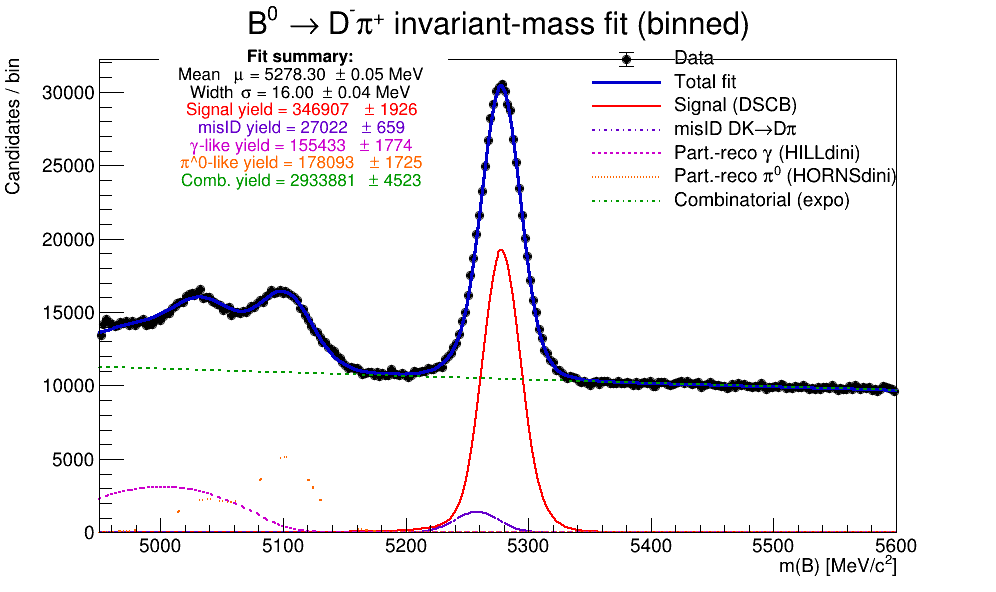



[28 RooFit INFO/Eval messages suppressed for readability]


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Info in <TCanvas::Print>: png file /tmp/fit_1762367590.png has been created



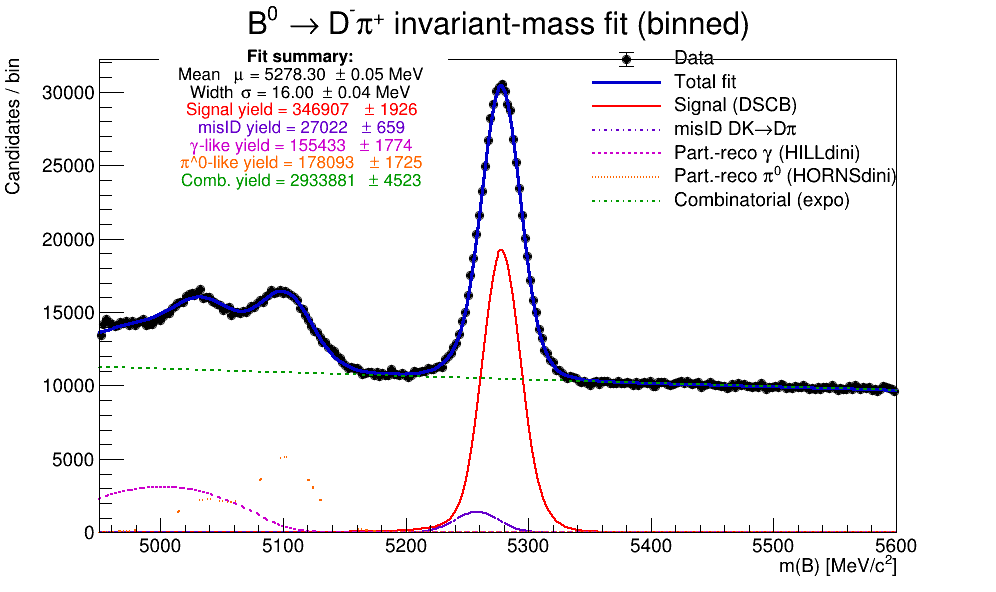

In [7]:
TREE_PATH  = "Tuple_Bd2DPi/DecayTree"
USE_SUBSET = False
SUBSET_N   = 50_000
NBINS      = 280
COMB_MODEL = "expo"     # exponential combinatorial

D_MASS, D_WINDOW_MAX = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.

MB_SIG   = 5278.0
SIG_WIN  = 25.0
SB1      = (4950., 5100.)
SB2      = (5450., 5600.)

# ROOT + custom PDFs
try:
    print("[pdf] Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))
except Exception as e:
    print("[pdf] Warning: could not load HILLdini/HORNSdini:", e)
def valerr(fitres, name):
    """Return (value, error) for parameter 'name' from RooFitResult."""
    p = fitres.floatParsFinal().find(name)
    return (p.getVal(), p.getError()) if p else (float('nan'), float('nan'))
# Read arrays once (fast scan)
branches = [
    "lab2_MASS","lab2_END_VCHI2DOF","lab2_P","lab2_THETA","lab2_PHI",
    "lab1_PIDK","lab1_P","lab1_THETA","lab1_PHI","lab1_TRACK_GhostProb","lab1_MINIPCHI2",
    "lab0_END_VCHI2DOF","lab0_OWNPVDIRA","lab0_OWNPVFDCHI2","lab0_OWNPVIPCHI2"
]
pool, need, kept = [], (SUBSET_N if USE_SUBSET else float("inf")), 0
for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="80 MB",
                   library="np", allow_missing=True),
    desc="Reading tuples"
):
    finite = np.ones_like(arrays["lab2_MASS"], dtype=bool)
    for b in branches: finite &= np.isfinite(arrays[b])
    mB_pi, _ = build_masses(arrays)
    if USE_SUBSET and kept < need:
        idx = np.flatnonzero(finite)
        if idx.size:
            cut_to = int(min(idx.size, need - kept))
            arrays = {k: v[idx[:cut_to]] for k,v in arrays.items()}
            mB_pi  = mB_pi[idx[:cut_to]]
            kept  += cut_to
    pool.append((arrays, mB_pi))

# Cut scan: maximise S/sqrt(S+B)
grid_PIDK     = [-10.0, -7.5, -5.0]
grid_DIRA     = [0.9990, 0.9993, 0.9995]
grid_FDCHI2   = [50., 80., 120.]
grid_IPCHI2   = [16., 9., 6.]
grid_GHOST    = [0.35, 0.30, 0.25]
grid_MINIPCHI2= [0., 4., 9.]
grid_DmassWin = [30., 24., 20.]

def counts_for_cuts(pidkMax, diraMin, fdchi2Min, ipchi2Max, ghostMax, minIPchi2, dWin):
    mvals = []
    for arrays, mB_pi in pool:
        base = (np.isfinite(mB_pi)
                & (arrays["lab0_END_VCHI2DOF"] < B_END_VCHI2DOF_MAX)
                & (arrays["lab2_END_VCHI2DOF"] < D_END_VCHI2DOF_MAX)
                & (np.abs(arrays["lab2_MASS"] - D_MASS) < dWin)
                & (arrays["lab1_PIDK"] < pidkMax)
                & (arrays["lab0_OWNPVDIRA"] > diraMin)
                & (arrays["lab0_OWNPVFDCHI2"] > fdchi2Min)
                & (arrays["lab0_OWNPVIPCHI2"] < ipchi2Max)
                & (arrays["lab1_TRACK_GhostProb"] < ghostMax)
                & (arrays["lab1_MINIPCHI2"] > minIPchi2))
        mvals.append(mB_pi[base])
    mvals = np.concatenate(mvals) if mvals else np.array([], float)
    if mvals.size == 0: return -np.inf, 0, 0, mvals
    s   = int(np.count_nonzero((mvals > MB_SIG-SIG_WIN) & (mvals < MB_SIG+SIG_WIN)))
    sb  = ((mvals > SB1[0]) & (mvals < SB1[1])) | ((mvals > SB2[0]) & (mvals < SB2[1]))
    bsb = int(np.count_nonzero(sb))
    scale = (2*SIG_WIN) / ((SB1[1]-SB1[0]) + (SB2[1]-SB2[0]))
    b = bsb * scale
    fom = s / np.sqrt(max(s+b, 1.0))
    return fom, s, b, mvals

best = (-np.inf, None, None, None, None)
for pidkMax, diraMin, fdchi2Min, ipchi2Max, ghostMax, minIPchi2, dWin in product(
    grid_PIDK, grid_DIRA, grid_FDCHI2, grid_IPCHI2, grid_GHOST, grid_MINIPCHI2, grid_DmassWin):
    fom, s, b, mvals = counts_for_cuts(pidkMax, diraMin, fdchi2Min, ipchi2Max, ghostMax, minIPchi2, dWin)
    if fom > best[0]:
        best = (fom, (pidkMax, diraMin, fdchi2Min, ipchi2Max, ghostMax, minIPchi2, dWin), s, b, mvals)

fom, (pidkMax, diraMin, fdchi2Min, ipchi2Max, ghostMax, minIPchi2, dWin), s, b, mvals = best
print(f"[scan] Best S/sqrt(S+B) = {fom:.3f}")
print(f"       PIDK<{pidkMax:.1f}, DIRA>{diraMin:.5f}, FDCHI2>{fdchi2Min:.0f}, "
      f"IPCHI2<{ipchi2Max:.0f}, Ghost<{ghostMax:.2f}, MINIPCHI2>{minIPchi2:.0f}, "
      f"|m(D)-m_D|<{dWin:.0f} MeV")

vals_all = []
for arrays, mB_pi in tqdm(pool, desc="Apply best cuts"):
    sel = (np.isfinite(mB_pi)
           & (arrays["lab0_END_VCHI2DOF"] < B_END_VCHI2DOF_MAX)
           & (arrays["lab2_END_VCHI2DOF"] < D_END_VCHI2DOF_MAX)
           & (np.abs(arrays["lab2_MASS"] - D_MASS) < dWin)
           & (arrays["lab1_PIDK"] < pidkMax)
           & (arrays["lab0_OWNPVDIRA"] > diraMin)
           & (arrays["lab0_OWNPVFDCHI2"] > fdchi2Min)
           & (arrays["lab0_OWNPVIPCHI2"] < ipchi2Max)
           & (arrays["lab1_TRACK_GhostProb"] < ghostMax)
           & (arrays["lab1_MINIPCHI2"] > minIPchi2))
    vals_all.append(mB_pi[sel])
vals = np.concatenate(vals_all) if vals_all else np.array([], float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build] after optimized cuts — kept {vals.size:,} candidates")
assert vals.size > 0, "No events after optimized cuts."

# RooDataHist + sideband slope
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    y, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, y, 1)[0]
else:
    coef = 0.0

hist, _ = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("h","h", NBINS, mmin, mmax)
for i, yb in enumerate(hist, start=1): dhist.SetBinContent(i, float(yb))
dh = ROOT.RooDataHist("dh","binned Dpi", ROOT.RooArgList(m), dhist)

# Model (DSCB + misID + partial reco + expo combi)
mu  = ROOT.RooRealVar("mu","mean", 5278, 5230, 5325)
sig = ROOT.RooRealVar("sig","sigma", 16, 8, 30)
aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-8,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB",  m, mu, sig, aL, nL)
sigR  = ROOT.RooCBShape("sigR","right CB", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.05,0.95)
SIG   = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

dMis   = ROOT.RooRealVar("dMis","DK->Dpi shift",45,20,70)
mu_mis = ROOT.RooFormulaVar("mu_mis","@0-@1", ROOT.RooArgList(mu,dMis))
sig_mis= ROOT.RooRealVar("sig_mis","misID width",18,10,35)
MIS    = ROOT.RooGaussian("MIS","misID DK->Dpi", m, mu_mis, sig_mis)

# Partial reco
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# Exponential combinatorial
b = ROOT.RooRealVar("b_slope","expo slope", -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)

# Yields (wider ranges)
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","signal yield", 0.18*Ntot, 0.0, 3.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","misID yield",  0.01*Ntot, 0.0, 0.25*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",  0.03*Ntot, 0.0, 2.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",    0.01*Ntot, 0.0, 2.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",  0.75*Ntot, 0.0, 3.0*Ntot)

pdf = ROOT.RooAddPdf("pdf","Dpi model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

# Optional weak priors (help keep misID from being "eaten" by expo)
gDmis = ROOT.RooGaussian("gDmis","prior dMis", dMis, RF.RooConst(45.0), RF.RooConst(8.0))
# Weak priors on Ng/Npi would go here if the partial-reco yields need constraining:
# mu_Ng, sig_Ng  = 0.03*Ntot, max(1.0, 0.03*Ntot)
# mu_Npi,sig_Npi = 0.01*Ntot, max(1.0, 0.01*Ntot)
# gNg  = ROOT.RooGaussian("gNg","weak Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
# gNpi = ROOT.RooGaussian("gNpi","weak Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints = ROOT.RooArgSet(gDmis)  # add gNg,gNpi later if useful

# Explicit NLL + RooMinimizer, rather than fitTo, so the minimiser strategy is set directly
# widen ranges to avoid boundary pinning
for r in (Nsig,Nmis,Ng,Npi,Ncomb):
    r.setRange(0., 3.0*Ntot)
nll = pdf.createNLL(
    dh,
    RF.Extended(True),
    RF.Offset(True),
    RF.ExternalConstraints(constraints)  # safe & weak
)
minim = ROOT.RooMinimizer(nll)
minim.setPrintLevel(-1)
minim.setStrategy(2)
minim.setEps(1e-6)
tfit = time.time()
minim.minimize("Minuit2","Migrad")
minim.minimize("Minuit2","Hesse")
fitres = minim.save()
print(f"[fit] status={fitres.status()}  covQual={fitres.covQual()}  time={time.time()-tfit:.1f}s")

# Plot (values+errors from fitres!)
mu_v,  mu_e  = valerr(fitres,"mu")
sig_v, sig_e = valerr(fitres,"sig")
Nsig_v,  Nsig_e  = valerr(fitres,"Nsig")
Nmis_v,  Nmis_e  = valerr(fitres,"Nmis")
Ng_v,    Ng_e    = valerr(fitres,"Ng")
Npi_v,   Npi_e   = valerr(fitres,"Npi")
Ncomb_v, Ncomb_e = valerr(fitres,"Ncomb")

frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_{int(time.time())}","DpiFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                 "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal (DSCB)",               "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID DK#rightarrowD#pi",     "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial (expo)",        "l")
leg.Draw()

box = ROOT.TPaveText(0.16, 0.68, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu_v:.2f} #pm {mu_e:.2f} MeV")
box.AddText(f"Width #sigma = {sig_v:.2f} #pm {sig_e:.2f} MeV")
t = box.AddText(f"Signal yield = {Nsig_v:.0f} #pm {Nsig_e:.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"misID yield = {Nmis_v:.0f} #pm {Nmis_e:.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like yield = {Ng_v:.0f} #pm {Ng_e:.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi_v:.0f} #pm {Npi_e:.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb_v:.0f} #pm {Ncomb_e:.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_{int(time.time())}.png"; c.SaveAs(tmp_png)
ipydisplay(IPyImage(filename=tmp_png))